1.2: Sobreajuste, subajuste y validación cruzada


**Objetivo:** Comparar modelos simples y complejos, e introducir validación cruzada.  
**Dataset:** `rendimiento_estudiantil.csv`
Usar en **Google Colab** o en Jupyter.

## Actividades de la sesión

1. Cargar y revisar el dataset.  
2. Preparar variables de entrada y salida.  
3. Entrenar el modelo.  
4. Evaluar resultados.  
5. Interpretar lo que ocurrió.  
6. Interpretación.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from pathlib import Path
import pandas as pd

def cargar_csv(nombre_archivo):
    rutas = [
        Path(nombre_archivo),
        Path("../datasets") / nombre_archivo,
        Path("datasets") / nombre_archivo,
        Path("/content") / nombre_archivo,
        Path("/content/datasets") / nombre_archivo,
    ]
    for ruta in rutas:
        if ruta.exists():
            print(f"Archivo encontrado en: {ruta}")
            return pd.read_csv(ruta)
    raise FileNotFoundError(
        f"No se encontró {nombre_archivo}. Súbelo a Colab o colócalo en la carpeta datasets."
    )


In [5]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


In [6]:
df = cargar_csv("rendimiento_estudiantil.csv")
df = df[["horas_estudio", "promedio_final"]].copy()
df.head()


Archivo encontrado en: rendimiento_estudiantil.csv


,horas_estudio,promedio_final
0,9.9,100.0
1,5.9,96.7
2,11.3,100.0
3,11.8,100.0
4,3.1,94.0


## Objetivo

Para visualizar mejor el sobreajuste, se utilizará una sola variable:
`horas_estudio`.

Probaremos modelos polinómicos con diferentes grados.


In [7]:
X = df[["horas_estudio"]]
y = df["promedio_final"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


In [8]:
resultados = []

for grado in [1, 2, 8]:
    modelo = Pipeline([
        ("poly", PolynomialFeatures(degree=grado, include_bias=False)),
        ("reg", LinearRegression())
    ])
    modelo.fit(X_train, y_train)

    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)

    cv_scores = cross_val_score(
        modelo, X, y, cv=5, scoring="neg_root_mean_squared_error"
    )

    resultados.append({
        "grado": grado,
        "R2_train": r2_score(y_train, pred_train),
        "R2_test": r2_score(y_test, pred_test),
        "RMSE_cv_promedio": -cv_scores.mean()
    })

resultados_df = pd.DataFrame(resultados).round(4)
resultados_df


,grado,R2_train,R2_test,RMSE_cv_promedio
0,1,0.2209,0.1268,3.4205
1,2,0.2526,0.1195,3.3614
2,8,0.2789,0.0720,3.5319


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


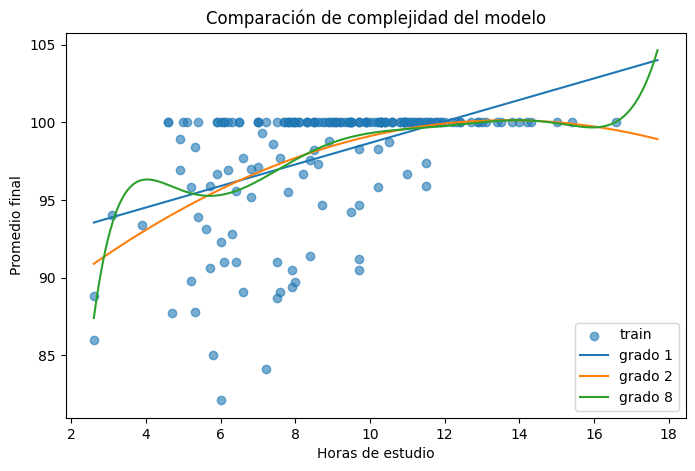

In [9]:
x_linea = np.linspace(X["horas_estudio"].min(), X["horas_estudio"].max(), 300).reshape(-1, 1)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, alpha=0.6, label="train")

for grado in [1, 2, 8]:
    modelo = Pipeline([
        ("poly", PolynomialFeatures(degree=grado, include_bias=False)),
        ("reg", LinearRegression())
    ])
    modelo.fit(X_train, y_train)
    y_linea = modelo.predict(x_linea)
    plt.plot(x_linea, y_linea, label=f"grado {grado}")

plt.xlabel("Horas de estudio")
plt.ylabel("Promedio final")
plt.title("Comparación de complejidad del modelo")
plt.legend()
plt.show()


## Interpretación

- Un modelo **muy simple** puede no capturar el patrón.
- Un modelo **muy complejo** puede ajustarse demasiado a entrenamiento.
- La **validación cruzada** ayuda a estimar qué tan estable es el modelo.


## Actividad:

1. Cambia los grados por `1, 3 y 12`.  
2. Repite el experimento.  
3. Anota cuál parece estar subajustado, cuál sobreajustado y cuál equilibrado.


In [ ]:
# Escribe aquí tu comparación adicional


## Conclusión
Redacta una conclusión breve respondiendo:
¿por qué no siempre el modelo más complejo es el mejor?
